In [1]:
import pandas as pd
import plotly.express as px

df3_mat = pd.read_csv("student-mat.csv", sep=",")
df3_mat["G3"] = df3_mat["G3"] / 2
df3_mat = df3_mat[["Walc", "Dalc", "G3"]]
df3_por = pd.read_csv("student-por.csv", sep=",")
df3_por["G3"] = df3_por["G3"] / 2
df3_por = df3_por[["Walc", "Dalc", "G3"]]


In [2]:
df3_mat.head()

,Walc,Dalc,G3
0,1,1,3.0
1,1,1,3.0
2,3,2,5.0
3,1,1,7.5
4,2,1,5.0


In [3]:
df3_por.head()

,Walc,Dalc,G3
0,1,1,5.5
1,1,1,5.5
2,3,2,6.0
3,1,1,7.0
4,2,1,6.5


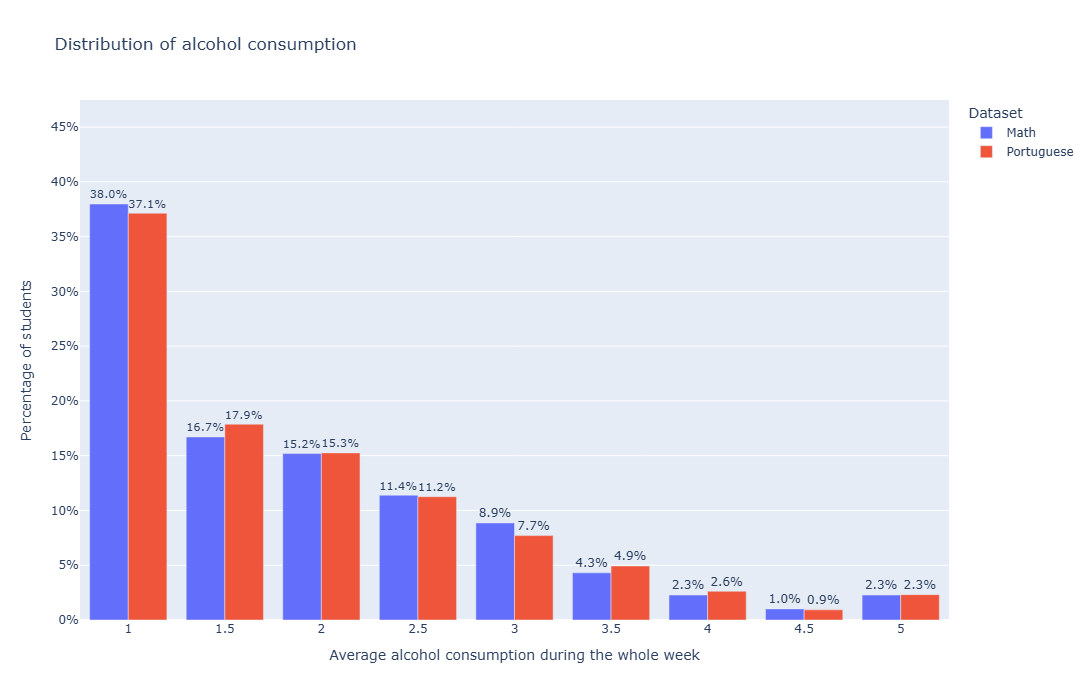

In [11]:
# Gemiddelde alcoholconsumptie berekenen
df3_mat["Alcohol"] = (df3_mat["Dalc"] + df3_mat["Walc"]) / 2
df3_por["Alcohol"] = (df3_por["Dalc"] + df3_por["Walc"]) / 2

# Relatieve frequenties berekenen
counts_mat = (
    df3_mat["Alcohol"]
    .value_counts(normalize=True)
    .sort_index()
)

counts_por = (
    df3_por["Alcohol"]
    .value_counts(normalize=True)
    .sort_index()
)

# Alle mogelijke alcoholscores verzamelen
all_scores = sorted(
    set(counts_mat.index).union(set(counts_por.index))
)

# DataFrame maken
counts = pd.DataFrame({
    "Alcohol": all_scores,
    "Math": counts_mat.reindex(all_scores, fill_value=0).values,
    "Portuguese": counts_por.reindex(all_scores, fill_value=0).values
})

# Omzetten naar long format voor Plotly
counts_long = counts.melt(
    id_vars="Alcohol",
    var_name="Dataset",
    value_name="Verhouding"
)

# Grafiek maken
fig = px.bar(
    counts_long,
    x="Alcohol",
    y="Verhouding",
    color="Dataset",
    barmode="group",
    text="Verhouding",
    labels={
        "Alcohol": "Average alcohol consumption during the whole week",
        "Verhouding": "Percentage of students"
    },
    title="Distribution of alcohol consumption"
)

fig.update_traces(
    texttemplate="%{y:.1%}",
    textposition="outside"
)

fig.update_layout(
    width=1000,
    height=700,
    yaxis_range=[0, counts_long["Verhouding"].max() * 1.25]
)

fig.update_yaxes(tickformat=".0%")

fig.show()

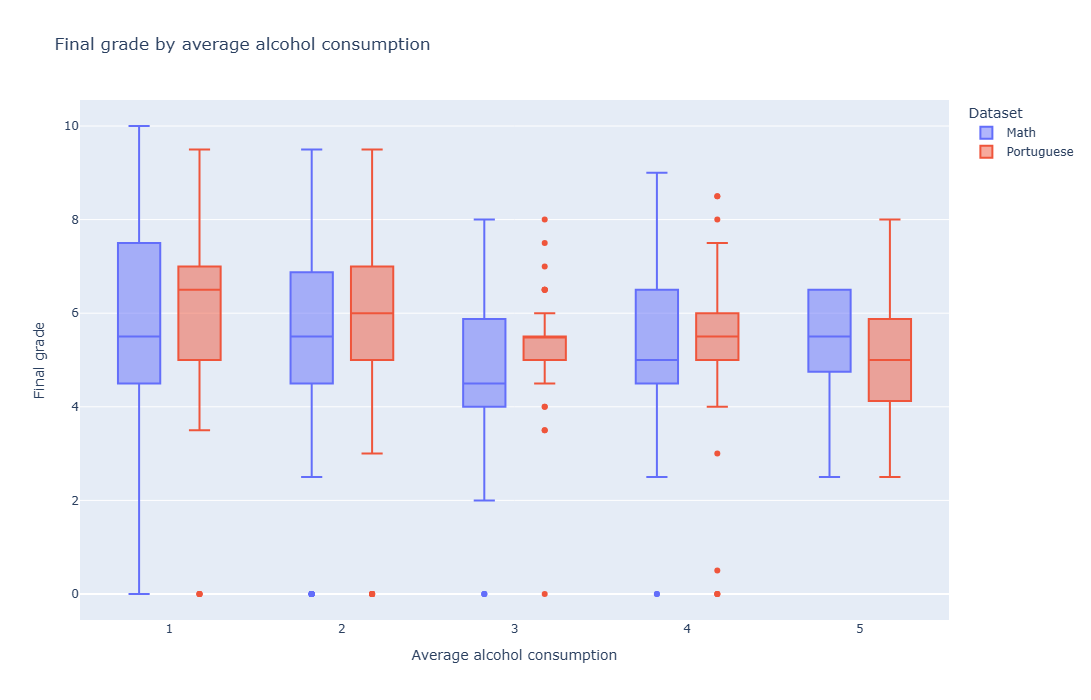

In [7]:
# Alcoholscore berekenen
df3_mat["Alcohol"] = ((df3_mat["Dalc"] + df3_mat["Walc"]) / 2).round()
df3_por["Alcohol"] = ((df3_por["Dalc"] + df3_por["Walc"]) / 2).round()

# Dataset-label toevoegen
mat = df3_mat.copy()
mat["Dataset"] = "Math"

por = df3_por.copy()
por["Dataset"] = "Portuguese"

# Samenvoegen
df_all = pd.concat([mat, por], ignore_index=True)

fig = px.box(
    df_all,
    x="Alcohol",
    y="G3",
    color="Dataset",
    labels={
        "Alcohol": "Average alcohol consumption",
        "G3": "Final grade"
    },
    title="Final grade by average alcohol consumption"
)

fig.update_layout(
    width=1000,
    height=700
)

fig.show()